In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks', font_scale=1.1)

### Original data file

In [ ]:
CSV_PATH = 'D:\implementation\p2psta\implementation\geolife_clean.csv' 
# ===== 1. 读数据 =====
df = pd.read_csv(
    CSV_PATH,
    parse_dates=['datetime'],
    dtype={'user': 'category'}
)
df.head()



<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
C:\Users\yezhan\AppData\Local\Temp\ipykernel_20084\3049680793.py:1: SyntaxWarning: invalid escape sequence '\i'
  CSV_PATH = 'D:\implementation\p2psta\implementation\geolife_clean.csv'


In [41]:


# ===== 2. 全局跨度统计（新增） =====
# 时间
t_min, t_max = df.datetime.min(), df.datetime.max()
# 经纬度
lat_min, lat_max = df.lat.min(), df.lat.max()
lon_min, lon_max = df.lon.min(), df.lon.max()

print(f'原始数据总行数 : {len(df):,}')
print(f'时间跨度      : {t_min}  ——  {t_max}')
print(f'总天数        : {(t_max - t_min).days + 1} 天')
print(f'纬度范围      : {lat_min:.6f}  –  {lat_max:.6f}')
print(f'经度范围      : {lon_min:.6f}  –  {lon_max:.6f}')
print(f'中心点        : {(lat_min+lat_max)/2:.6f}, {(lon_min+lon_max)/2:.6f}')

原始数据总行数 : 19,632,236
时间跨度      : 2007-04-12 01:31:32+00:00  ——  2012-07-27 00:31:20+00:00
总天数        : 1933 天
纬度范围      : 39.000000  –  40.999996
经度范围      : 115.000173  –  117.999978
中心点        : 39.999998, 116.500076


In [46]:
QUERIES = {
    'forbidden_city': {
        'lat_min': 39.906, 'lat_max': 39.923,
        'lon_min': 116.386, 'lon_max': 116.411,
        't_start': pd.Timestamp('2008-06-01 03:00:00', tz='UTC'),
        't_end': pd.Timestamp('2010-06-10 03:15:00', tz='UTC')
    },
    'beijing': {
        'lat_min': 39.5, 'lat_max': 40.2,
        'lon_min': 116.0, 'lon_max': 116.8,
        't_start': pd.Timestamp('2008-05-10 22:00:00', tz='UTC'),
        't_end': pd.Timestamp('2012-05-20 01:00:00', tz='UTC')
    }
}

In [47]:
def summarize(df, queries):
    """返回 dict：{query_name: {rows, users, trajs, first, last}}"""
    summary = {}
    for name, q in queries.items():
        mask = (
            (df.lat >= q['lat_min']) & (df.lat <= q['lat_max']) &
            (df.lon >= q['lon_min']) & (df.lon <= q['lon_max']) &
            (df.datetime >= q['t_start']) & (df.datetime <= q['t_end'])
        )
        sub = df[mask]
        summary[name] = {
            'rows': int(mask.sum()),
            'users': sub['user'].nunique(),
            'trajs': sub['traj_id'].nunique(),
            'first': sub['datetime'].min(),
            'last': sub['datetime'].max()
        }
    return summary

In [48]:
# 执行统计并打印
summary = summarize(df, QUERIES)

for name, s in summary.items():
    print(f"\n=== {name} ===")
    print(f"rows : {s['rows']}")
    print(f"users: {s['users']}")
    print(f"trajs: {s['trajs']}")
    print(f"time : {s['first']}  ~  {s['last']}")

# 顺便打印全表指标
print('\n=== full file ===')
print(f'total rows : {len(df)}')
print(f'total users: {df["user"].nunique()}')
print(f'total trajs: {df["traj_id"].nunique()}')
print(f'time range : {df["datetime"].min()}  ~  {df["datetime"].max()}')


=== forbidden_city ===
rows : 52649
users: 50
trajs: 216
time : 2008-06-05 01:45:44+00:00  ~  2010-06-04 03:13:41+00:00

=== beijing ===
rows : 17999400
users: 139
trajs: 15385
time : 2008-05-10 22:00:00+00:00  ~  2012-05-19 11:55:15+00:00

=== full file ===
total rows : 19632236
total users: 179
total trajs: 17314
time range : 2007-04-12 01:31:32+00:00  ~  2012-07-27 00:31:20+00:00


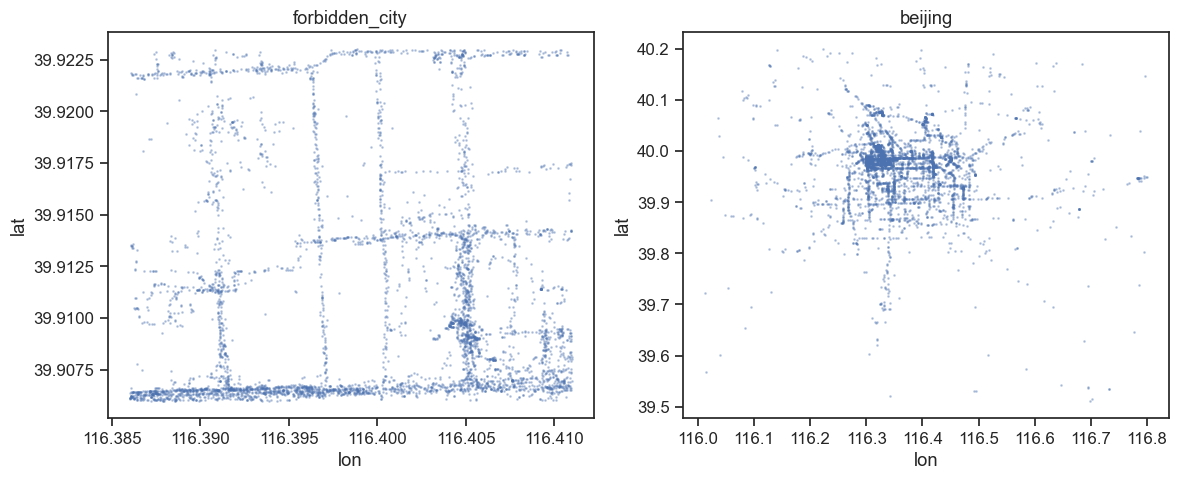

In [49]:
sns.set(style="ticks", font_scale=1.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, q) in zip(axes, QUERIES.items()):
    # 1. 先过滤
    mask = (
        (df.lat >= q['lat_min']) & (df.lat <= q['lat_max']) &
        (df.lon >= q['lon_min']) & (df.lon <= q['lon_max']) &
        (df.datetime >= q['t_start']) & (df.datetime <= q['t_end'])
    )
    sub = df[mask]                       # 2. 拿到 sub
    if sub.empty:                        # 3. 防止空图
        print(f'{name} 无数据，跳过绘图')
        continue
    # 4. 再抽样
    sub = sub.sample(n=min(5000, len(sub)), random_state=42)
    ax.scatter(sub.lon, sub.lat, s=1, alpha=0.3)
    ax.set_title(name)
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

plt.tight_layout()
plt.show()

### My data files

In [1]:
BASE_DIR = r'D:\implementation\p2psta\implementation\results\run_20250917_134512'

files = {
    'forbidden_city': f'{BASE_DIR}/query_00_forbidden_city/query_results.csv',
    'beijing': f'{BASE_DIR}/query_01_beijing/query_results.csv'
}



In [4]:
dfs = {}
for name, path in files.items():
    df = pd.read_csv(
        path,
        parse_dates=['datetime'],
        dtype={'traj_id': str}
    )
    df['traj_id'] = df['traj_id'].str.strip()

    dfs[name] = df
    print(f'{name}: {len(df)} 行')

forbidden_city: 52649 行
beijing: 17999400 行


In [5]:
summary = {}
for name, df in dfs.items():
    summary[name] = {
        'rows': len(df),
        'users': df['user'].nunique(),
        'trajs': df['traj_id'].nunique(),
        'first': df['datetime'].min(),
        'last': df['datetime'].max()
    }

for name, s in summary.items():
    print(f'\n=== {name} ===')
    print(f"rows : {s['rows']}")
    print(f"users: {s['users']}")
    print(f"trajs: {s['trajs']}")
    print(f"time : {s['first']}  ~  {s['last']}")


=== forbidden_city ===
rows : 52649
users: 50
trajs: 216
time : 2008-06-05 01:45:44+00:00  ~  2010-06-04 03:13:41+00:00

=== beijing ===
rows : 17999400
users: 139
trajs: 15385
time : 2008-05-10 22:00:00+00:00  ~  2012-05-19 11:55:15+00:00


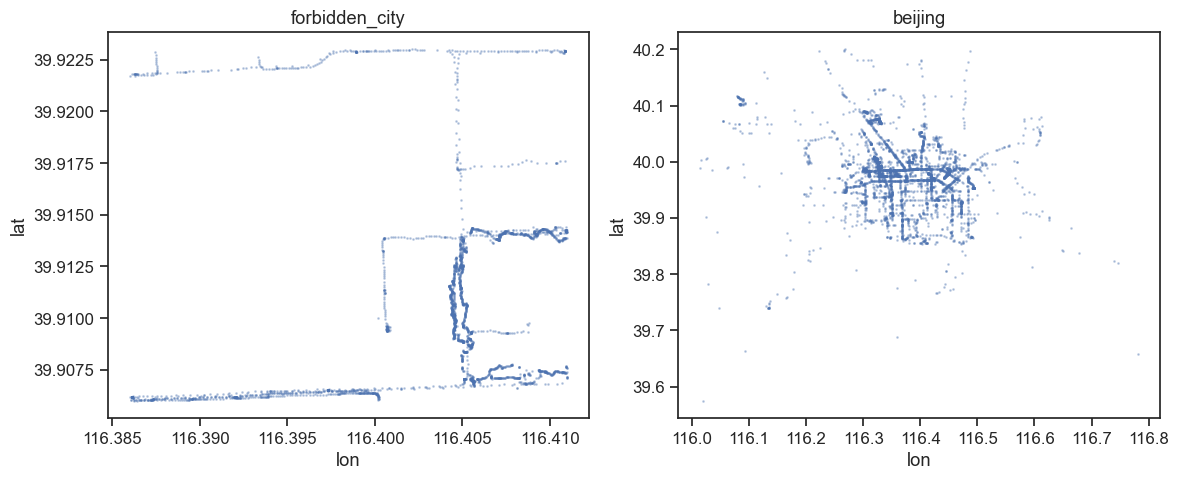

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, dfs.items()):
    if df.empty:
        ax.set_title(f'{name} 无数据')
        continue
    plot_df = df.sample(n=min(5000, len(df)), random_state=42)
    ax.scatter(plot_df.lon, plot_df.lat, s=1, alpha=0.3)
    ax.set_title(name)
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

plt.tight_layout()
plt.show()